# 3 - Supplementary figure S2

**Figure S2** - d' and median reaction time as a function of saccade onset time
relative to sound onset, split by saccade-sound congruency.

Rows = metrics; columns = experiments. Same conventions as the main figures.
The comparison against baseline is omitted for d' (the estimates are volatile
where a subject-window cell has missing values or unequal samples).

**Input**   `data_preprocessed/{EX_1,EX_9,EX_7,EX_3}/long_format_alt_all.csv`
**Outputs** `summaries/plots/paper_fig_dprime_rt.{png,pdf}`

Figures S1 and S3 come from `04_stats_anova.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
import os
import sys
import importlib

sys.path.insert(0, 'src')

import peri_sac
import config
import src.analysis_heatmap as analysis_heatmap

importlib.reload(peri_sac)
importlib.reload(config)
importlib.reload(analysis_heatmap)

from peri_sac import (
    calculate_running_window_metrics,
    plot_single_condition,
    test_pairwise_conditions,
    test_condition_vs_baseline,
    calculate_baseline_metrics_from_trials,
    apply_fdr_correction,
    plot_significance_bars,
    DEFAULT_METRICS,
    COLOR_PALETTES,
)
from config import (
    EXPERIMENT_CONFIGS,
    prepare_alternative_data,
    build_filter,
    METRIC_COLUMN_MAP,
    AMPLITUDE_UNIT_LABEL,
)
from src.analysis_heatmap import plot_amplitude_time_heatmap

%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42  # embed TrueType fonts in PDF (not outlines)
plt.rcParams['ps.fonttype'] = 42

## Shared Configuration

In [2]:
# ====================================================================
# EXPERIMENTS
# ====================================================================

EXPERIMENTS = ['EX_1', 'EX_9', 'EX_7', 'EX_3']
EXPERIMENT_LABELS = [
    'Exp 1a. binaural-direction',
    'Exp 1b. binaural-direction',
    'Exp 2. monaural-direction',
    'Exp 3. monaural-pitch',
]

# ====================================================================
# TIME / WINDOW PARAMETERS  (shared by line plots and heatmaps)
# ====================================================================

SOUND_SELECTION  = 'both'
TIME_REFERENCE   = 'time_from_sound_to_sacc_start'
TIME_RANGE       = (-500, 1000)
WINDOW_SIZE      = 100
STEP_SIZE        = 25
BASELINE_RANGE   = (-500, 0)

# ====================================================================
# SHARED FIGURE STYLE  (used by every figure cell below)
# ====================================================================

LINE_H    = 3.5   # height of each line-plot row (inches)
CBAR_FRAC = 0.05  # colorbar width as fraction of column width
FONTSIZE  = 12

MIN_CORRECTION_N = 5

OUTPUT_PATH = Path('summaries') / 'plots'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(f'Experiments   : {EXPERIMENTS}')
print(f'Labels        : {EXPERIMENT_LABELS}')
print(f'Time reference: {TIME_REFERENCE}')
print(f'Baseline range: {BASELINE_RANGE} ms')

Experiments   : ['EX_1', 'EX_9', 'EX_7', 'EX_3']
Labels        : ['Exp 1a. binaural-direction', 'Exp 1b. binaural-direction', 'Exp 2. monaural-direction', 'Exp 3. monaural-pitch']
Time reference: time_from_sound_to_sacc_start
Baseline range: (-500, 0) ms


## Load Data & Compute Running-Window Metrics

In [3]:
experiment_data = {}

for EXPERIMENT in EXPERIMENTS:
    print(f'\n=== {EXPERIMENT} ===')

    data_raw = pd.read_csv(
        os.path.join(f'data_preprocessed/{EXPERIMENT}', 'long_format_alt_all.csv'),
        low_memory=False,
    )
    print(f'  Rows: {len(data_raw):,}  |  Subjects: {data_raw["id_subject"].nunique()}')

    data = prepare_alternative_data(data_raw, sound_selection=SOUND_SELECTION)
    analysis_filter     = build_filter(data)
    filter_consistent   = analysis_filter & (data['consistent'] == True)
    filter_inconsistent = analysis_filter & (data['consistent'] == False)

    sdt_column = EXPERIMENT_CONFIGS[EXPERIMENT].get('sdt_column')

    results_consistent = calculate_running_window_metrics(
        data, filter_consistent, TIME_REFERENCE,
        window_size=WINDOW_SIZE, step_size=STEP_SIZE,
        time_range=TIME_RANGE, baseline_range=BASELINE_RANGE,
        sdt_column=sdt_column, sdt_min_correction_n=MIN_CORRECTION_N,
    )
    results_inconsistent = calculate_running_window_metrics(
        data, filter_inconsistent, TIME_REFERENCE,
        window_size=WINDOW_SIZE, step_size=STEP_SIZE,
        time_range=TIME_RANGE, baseline_range=BASELINE_RANGE,
        sdt_column=sdt_column, sdt_min_correction_n=MIN_CORRECTION_N,
    )

    experiment_data[EXPERIMENT] = {
        'consistent':          results_consistent,
        'inconsistent':        results_inconsistent,
        'data':                data,
        'filter_consistent':   filter_consistent,
        'filter_inconsistent': filter_inconsistent,
        'sdt_column':          sdt_column,
    }
    print(f'  Windows: {results_consistent["window_center"].nunique()}  |  SDT col: {sdt_column}')

print('\nDone.')


=== EX_1 ===
  Rows: 248,227  |  Subjects: 52
  Windows: 61  |  SDT col: sound_direction

=== EX_9 ===
  Rows: 192,094  |  Subjects: 40
  Windows: 61  |  SDT col: sound_direction

=== EX_7 ===
  Rows: 188,481  |  Subjects: 40
  Windows: 61  |  SDT col: sound_direction

=== EX_3 ===
  Rows: 218,688  |  Subjects: 46
  Windows: 61  |  SDT col: sound_pitch

Done.


In [4]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# Median RT and IQR per experiment — used for reference lines on all plots
PERI_MEDIAN_RT    = {}
PERI_RT_QUARTILES = {}
_peri_subj_rt     = {}   # per-subject median RT, used for between-experiment tests below

for _exp in EXPERIMENTS:
    _data = experiment_data[_exp]['data']
    _fc   = experiment_data[_exp]['filter_consistent']
    _fi   = experiment_data[_exp]['filter_inconsistent']
    _rt   = _data[(_fc | _fi) & (_data['response_given'] == 1)]['rt']
    _rt   = _rt[_rt > 0]
    PERI_MEDIAN_RT[_exp]    = float(_rt.median())
    PERI_RT_QUARTILES[_exp] = (float(_rt.quantile(0.25)), float(_rt.quantile(0.75)))
    # Per-subject median RT for non-parametric between-experiment comparison
    _peri_subj_rt[_exp] = (
        _data[(_fc | _fi) & (_data['response_given'] == 1) & (_data['rt'] > 0)]
        .groupby('id_subject')['rt'].median()
    )
    print(f'{_exp}: median RT = {PERI_MEDIAN_RT[_exp]:.0f} ms  '
          f'[Q1={PERI_RT_QUARTILES[_exp][0]:.0f}, Q3={PERI_RT_QUARTILES[_exp][1]:.0f}]  '
          f'n={len(_peri_subj_rt[_exp])}')

# ── Pairwise Mann-Whitney U tests between experiments (FDR corrected) ─
_exp_labels = EXPERIMENT_LABELS if EXPERIMENT_LABELS else EXPERIMENTS
_pairs      = list(combinations(range(len(EXPERIMENTS)), 2))
_pvals_mw   = []
_mw_rows    = []
for i, j in _pairs:
    _u, _p = mannwhitneyu(
        _peri_subj_rt[EXPERIMENTS[i]], _peri_subj_rt[EXPERIMENTS[j]],
        alternative='two-sided')
    _mw_rows.append((EXPERIMENTS[i], EXPERIMENTS[j], _exp_labels[i], _exp_labels[j], _u, _p))
    _pvals_mw.append(_p)

_, _pvals_mw_corr, _, _ = multipletests(_pvals_mw, method='fdr_bh')

print(f"\nPairwise Mann-Whitney U  (FDR-corrected, per-subject median RT):")
for (_ei, _ej, _li, _lj, _u, _p_raw), _p_corr in zip(_mw_rows, _pvals_mw_corr):
    _sig = '*' if _p_corr < 0.05 else ' '
    print(f"  {_li}  vs  {_lj}"
          f"\n    U = {_u:.0f},  p = {_p_raw:.4f},  FDR-p = {_p_corr:.4f}  {_sig}")

EX_1: median RT = 634 ms  [Q1=517, Q3=799]  n=52
EX_9: median RT = 653 ms  [Q1=534, Q3=819]  n=40
EX_7: median RT = 556 ms  [Q1=456, Q3=709]  n=39
EX_3: median RT = 778 ms  [Q1=653, Q3=965]  n=46

Pairwise Mann-Whitney U  (FDR-corrected, per-subject median RT):
  Exp 1a. binaural-direction  vs  Exp 1b. binaural-direction
    U = 896,  p = 0.2600,  FDR-p = 0.2600   
  Exp 1a. binaural-direction  vs  Exp 2. monaural-direction
    U = 1421,  p = 0.0011,  FDR-p = 0.0013  *
  Exp 1a. binaural-direction  vs  Exp 3. monaural-pitch
    U = 343,  p = 0.0000,  FDR-p = 0.0000  *
  Exp 1b. binaural-direction  vs  Exp 2. monaural-direction
    U = 1204,  p = 0.0000,  FDR-p = 0.0000  *
  Exp 1b. binaural-direction  vs  Exp 3. monaural-pitch
    U = 334,  p = 0.0000,  FDR-p = 0.0000  *
  Exp 2. monaural-direction  vs  Exp 3. monaural-pitch
    U = 84,  p = 0.0000,  FDR-p = 0.0000  *


In [5]:
import math

def _make_3_ticks(vmin, vmax):
    """Return [bottom, middle, top] ticks rounded to nice values inside [vmin, vmax].

    Uses ceil for the bottom and floor for the top so ticks never exceed the
    axis range (matches the version in analysis_heatmap.py).
    """
    vmid = (vmin + vmax) / 2
    span = abs(vmax - vmin)
    if span == 0:
        return [vmin]
    if max(abs(vmin), abs(vmax)) <= 1:
        lo  = math.ceil(vmin * 100) / 100
        hi  = math.floor(vmax * 100) / 100
        mid = round(vmid, 2)
    else:
        if span >= 50:
            scale = 10
        elif span >= 10:
            scale = 5
        elif span >= 1:
            scale = 1
        elif span >= 0.1:
            scale = 0.1
        else:
            scale = 0.05
        lo  = math.ceil(vmin / scale) * scale
        hi  = math.floor(vmax / scale) * scale
        mid = round(vmid / scale) * scale
    return sorted({lo, mid, hi})

## Figure: d' and RT Grid

Line plots (consistent vs inconsistent, mean ± SEM) for SDT sensitivity (d') and median reaction time.
Rows = metrics; columns = experiments. All formatting follows the paper figure conventions.

In [20]:
# ====================================================================
# FIGURE CONFIGURATION — d' and RT Grid
# ====================================================================

DPRIME_RT_METRICS = ['d_prime', 'rt_median']

DPRIME_RT_YLABELS = {
    'd_prime':   "d'",
    'rt_median': 'Median RT (ms)',
}

DPRIME_RT_VCENT      = {m: {} for m in DPRIME_RT_METRICS}
DPRIME_RT_LINE_YLIMS = {}

for _metric in DPRIME_RT_METRICS:
    _per_exp = []
    for _exp in EXPERIMENTS:
        _ed = experiment_data[_exp]
        _combined = pd.concat([_ed['consistent'], _ed['inconsistent']])
        _bl_vals = _combined.loc[
            (_combined['window_center'] >= BASELINE_RANGE[0]) &
            (_combined['window_center'] <= BASELINE_RANGE[1]),
            _metric,
        ].dropna()
        _vcent = float(_bl_vals.mean())
        DPRIME_RT_VCENT[_metric][_exp] = _vcent

        if _metric == 'd_prime':
            # Symmetric ±1 around baseline mean
            _ymin, _ymax = _vcent - 1, _vcent + 1
        elif _metric == 'rt_median':
            # Fixed offsets: -100 below mean (no tick), +200 above mean (top tick)
            # mean lands at 1/3 from bottom (100 / 300 total range)
            _ymin, _ymax = _vcent - 100, _vcent + 200

        _per_exp.append((_ymin, _ymax))
        print(f'{_exp}  {_metric}: center={_vcent:.3f}  vlim=({_ymin:.3f}, {_ymax:.3f})')
    DPRIME_RT_LINE_YLIMS[_metric] = _per_exp
    print()

EX_1  d_prime: center=0.966  vlim=(-0.034, 1.966)
EX_9  d_prime: center=1.189  vlim=(0.189, 2.189)
EX_7  d_prime: center=3.573  vlim=(2.573, 4.573)
EX_3  d_prime: center=2.269  vlim=(1.269, 3.269)

EX_1  rt_median: center=652.031  vlim=(552.031, 852.031)
EX_9  rt_median: center=678.360  vlim=(578.360, 878.360)
EX_7  rt_median: center=582.867  vlim=(482.867, 782.867)
EX_3  rt_median: center=816.012  vlim=(716.012, 1016.012)



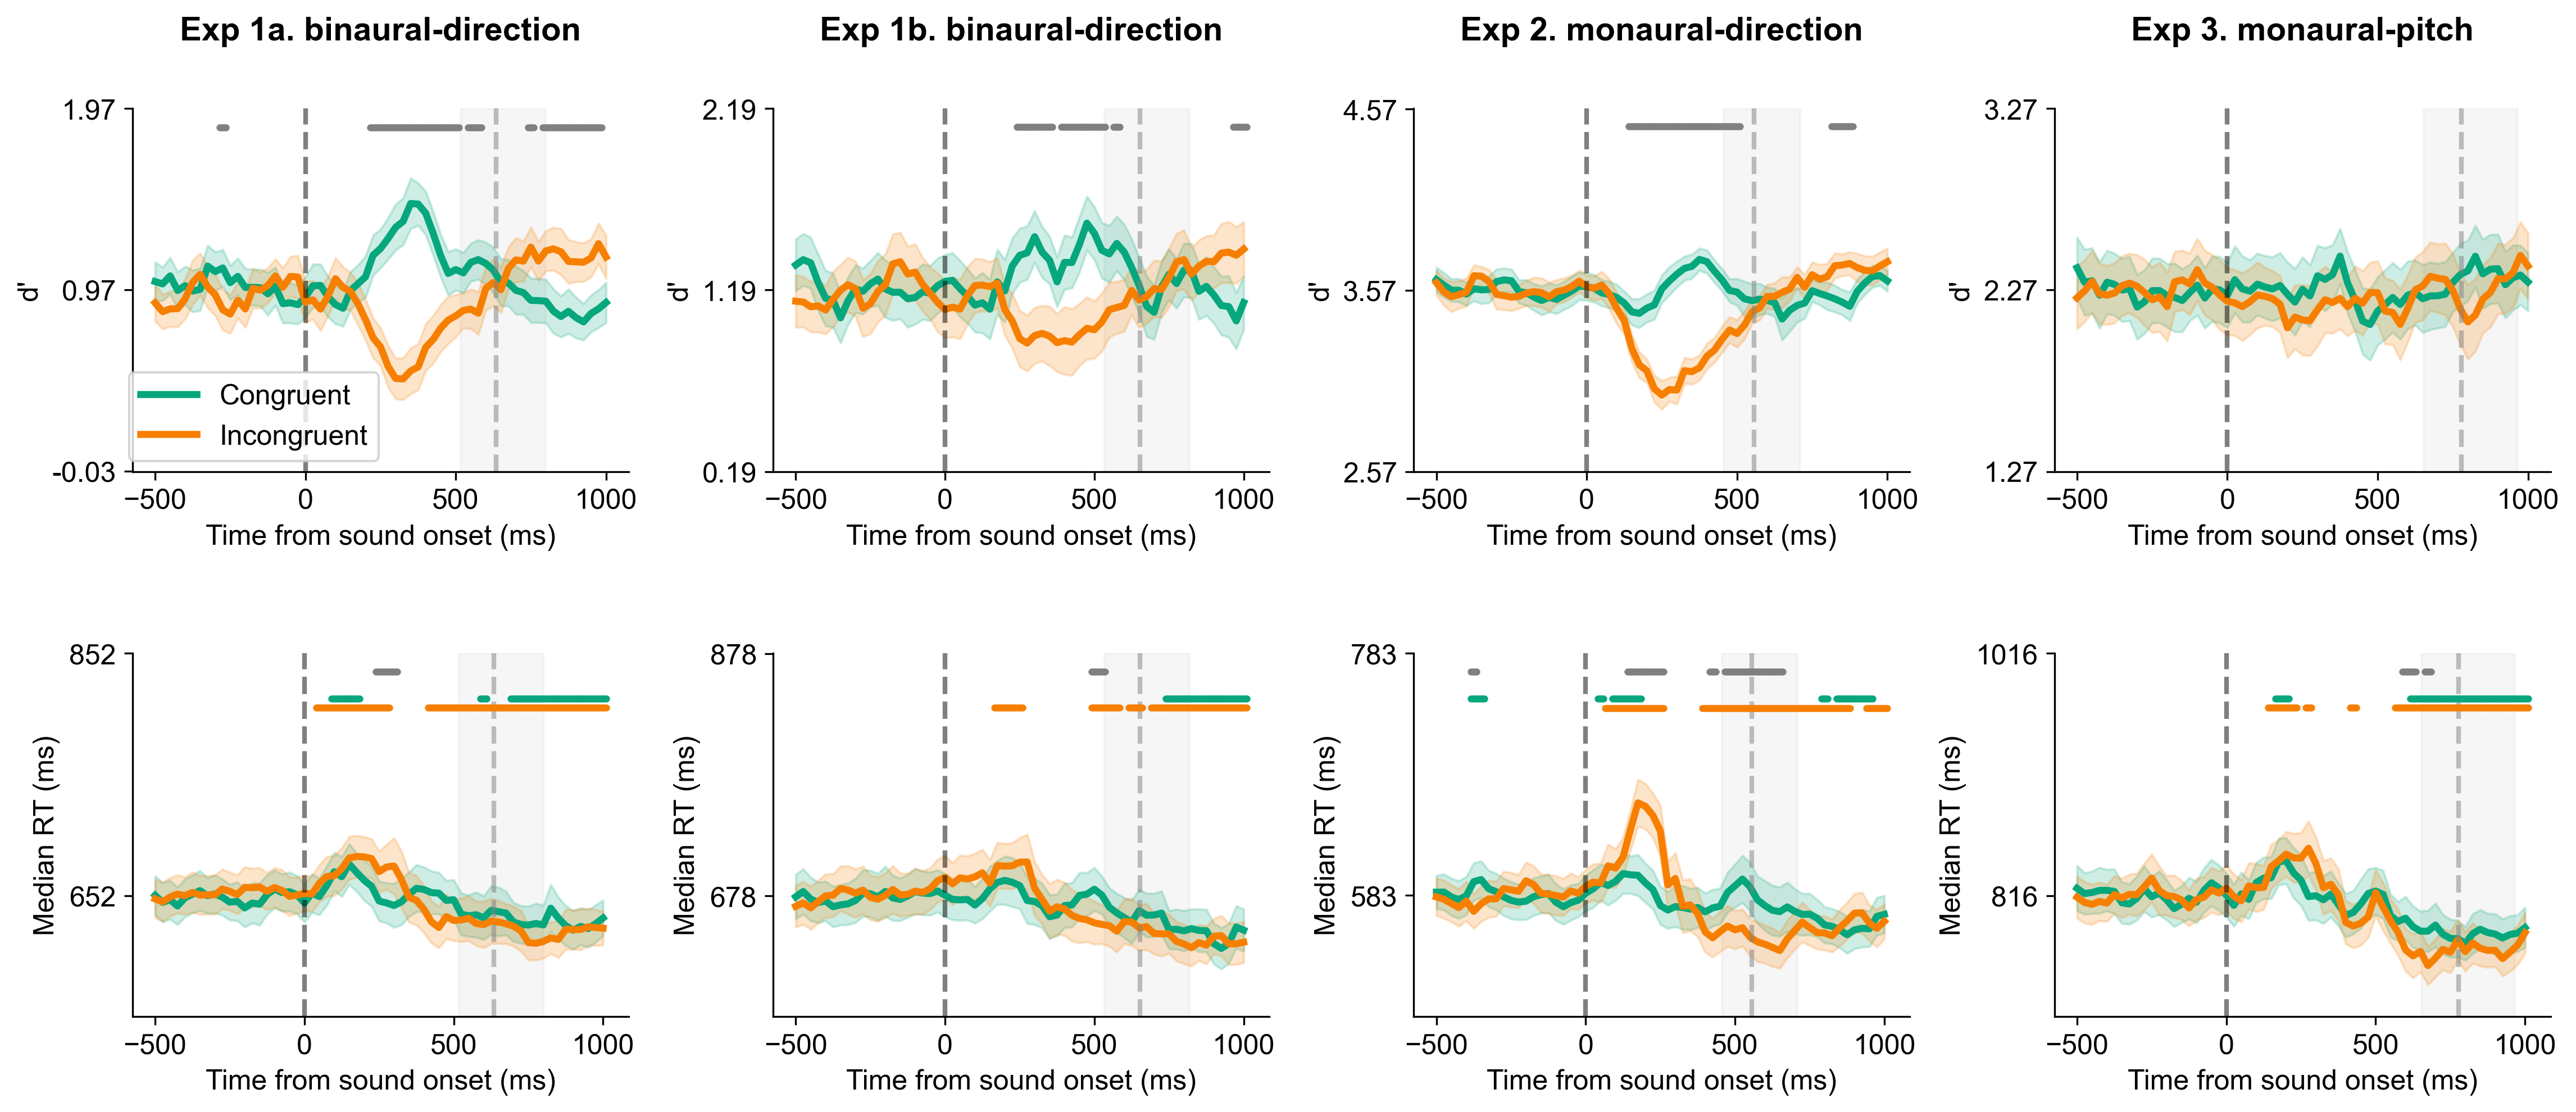

Done.


In [ ]:
colors          = COLOR_PALETTES[2]
condition_names = ('Congruent', 'Incongruent')
col_labels_fig  = EXPERIMENT_LABELS if EXPERIMENT_LABELS else EXPERIMENTS

LEGEND_POS = (0.53, -0.03)
CELL_W   = 4.7   # width of each experiment column

n_rows = len(DPRIME_RT_METRICS)
n_cols = len(EXPERIMENTS)
fig_w  = CELL_W * n_cols
fig_h  = LINE_H * n_rows

fig = plt.figure(figsize=(fig_w, fig_h))

outer_gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure = fig,
    hspace = 0.5,
    wspace = 0.2,
)

for metric_idx, metric in enumerate(DPRIME_RT_METRICS):
    for col_idx, exp_name in enumerate(EXPERIMENTS):
        ed           = experiment_data[exp_name]
        results_list = [ed['consistent'], ed['inconsistent']]

        # ── Significance testing ─────────────────────────────────────
        cols_keep = ['id_subject', 'window_center', metric]
        merged = results_list[0][cols_keep].rename(columns={metric: f'{metric}_cond0'})
        temp   = results_list[1][cols_keep].rename(columns={metric: f'{metric}_cond1'})
        merged = merged.merge(temp, on=['id_subject', 'window_center'], how='outer')

        sig   = {}
        tname = f'{metric}_cond0_vs_cond1'
        sig[tname] = []
        for wc in merged['window_center'].dropna().unique():
            wd = merged[merged['window_center'] == wc]
            r  = test_pairwise_conditions(wd, metric, '_cond0', '_cond1')
            r['window_center'] = wc
            sig[tname].append(r)

        for ci, filt in enumerate([ed['filter_consistent'], ed['filter_inconsistent']]):
            bd = calculate_baseline_metrics_from_trials(
                ed['data'][filt], BASELINE_RANGE, TIME_REFERENCE)
            tk = f'{metric}_cond{ci}_vs_baseline'
            sig[tk] = []
            for wc in merged['window_center'].dropna().unique():
                wd = merged[merged['window_center'] == wc]
                r  = test_condition_vs_baseline(
                    wd, bd, metric, metric_suffix=f'_cond{ci}',
                    baseline_range=BASELINE_RANGE, window_size=WINDOW_SIZE)
                r['window_center'] = wc
                sig[tk].append(r)

        # FDR corrected across all three comparisons at once: the family is
        # every test x every time window, not each comparison separately.
        sig = apply_fdr_correction(sig)

        # ── Subplot: [plot | spacer] ──────────────────────────────────
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 2,
            subplot_spec = outer_gs[metric_idx, col_idx],
            width_ratios = [1, CBAR_FRAC],
            wspace       = 0.05,
        )
        ax = fig.add_subplot(inner_gs[0])

        for ci, res_df in enumerate(results_list):
            plot_single_condition(ax, res_df, metric, colors[ci], condition_names[ci])

        ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.5)
        exp_rt   = PERI_MEDIAN_RT.get(exp_name)
        exp_rt_q = PERI_RT_QUARTILES.get(exp_name)
        if exp_rt:
            ax.axvline(exp_rt, color='gray', linestyle='--', linewidth=2, alpha=0.5)
            if exp_rt_q:
                ax.axvspan(exp_rt_q[0], exp_rt_q[1], color='lightgray', alpha=0.2, zorder=0)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=FONTSIZE, labelbottom=True)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontfamily('Arial')

        # Column title on first row only
        if metric_idx == 0:
            ax.set_title(
                col_labels_fig[col_idx], fontsize=FONTSIZE + 2, fontweight='bold',
                fontfamily='Arial', y=1.15)

        ax.set_ylabel(DPRIME_RT_YLABELS.get(metric, metric), fontsize=FONTSIZE, fontfamily='Arial')
        ax.set_xlabel('Time from sound onset (ms)', fontsize=FONTSIZE, fontfamily='Arial')

        # ── Y-axis limits (set BEFORE significance bars) ─────────────
        _ymin, _ymax = DPRIME_RT_LINE_YLIMS[metric][col_idx]
        ax.set_ylim(_ymin, _ymax)

        plot_significance_bars(ax, sig[f'{metric}_cond0_vs_cond1'], 0.05, 'grey', linewidth=3)
        baseline_start = 0.05 + 0.025 + 0.05
        for ci in range(2):
            tk = f'{metric}_cond{ci}_vs_baseline'
            if tk in sig:
                plot_significance_bars(
                    ax, sig[tk], baseline_start + ci * 0.025, colors[ci], linewidth=3)

        # ── Y ticks: per-metric ───────────────────────────────────────
        _vcent_val = DPRIME_RT_VCENT[metric][exp_name]
        if metric == 'd_prime':
            # 3 ticks: bottom / mean / top — 2 decimal places
            ax.set_yticks([round(_ymin, 2), round(_vcent_val, 2), round(_ymax, 2)])
            ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        elif metric == 'rt_median':
            # 2 ticks: mean (sits at 1/3 from bottom) and top — whole numbers
            ax.set_yticks([round(_vcent_val), round(_ymax)])
            ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))

        # ── Legend: first column, first row only ─────────────────────
        if metric_idx == 0 and col_idx == 0:
            legend_handles = [
                Line2D([0], [0], color=colors[0], linewidth=3, label=condition_names[0]),
                Line2D([0], [0], color=colors[1], linewidth=3, label=condition_names[1]),
            ]
            ax.legend(
                handles        = legend_handles,
                loc            = 'lower right',
                bbox_to_anchor = LEGEND_POS,
                prop           = {'family': 'Arial', 'size': FONTSIZE},
                frameon        = True,
            )

fig.savefig(
    OUTPUT_PATH / 'paper_fig_dprime_rt.png',
    dpi=300, bbox_inches='tight',
)
fig.savefig(
    OUTPUT_PATH / 'paper_fig_dprime_rt.pdf',
    bbox_inches='tight',
)
plt.show()
print('Done.')